In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import gc
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

2026-07-21 15:01:47.944972: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
years = [2008, 2009, 2010, 2011, 2012]
original_hrdps_dir = ("/results/forcing/atmospheric/GEM2.5/gemlam")
time_fixed_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/TimeFixed")

fixed_2008_filenames = {
    "gemlam_y2008m07d16.nc",
    "gemlam_y2008m07d17.nc",
    "gemlam_y2008m07d18.nc",
    "gemlam_y2008m07d19.nc",
    "gemlam_y2008m07d20.nc",
    "gemlam_y2008m07d21.nc",
    "gemlam_y2008m07d22.nc",
    "gemlam_y2008m07d23.nc",
    'gemlam_y2008m08d10.nc',
    "gemlam_y2008m08d11.nc",
    "gemlam_y2008m08d12.nc",
}

hrdps_files_by_year = {}
for year in years:
    original_files = glob.glob(os.path.join(original_hrdps_dir,f"gemlam_y{year}m??d??.nc"))
    files_by_name = {os.path.basename(file): file for file in original_files}
    if year == 2008:
        for filename in fixed_2008_filenames:
            fixed_file = os.path.join(time_fixed_dir,filename,)
            files_by_name[filename] = fixed_file

    files = [files_by_name[filename] for filename in sorted(files_by_name)]

    hrdps_files_by_year[year] = files

    print(year,":",files[0],"to",files[-1],f"({len(files)} files)")

2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc (366 files)
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc (365 files)
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc (365 files)
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc (365 files)
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc (366 files)


In [7]:
# Loading darldsets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()

with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [8]:
# Converts hourly HRDPS longwave_radiation from the 266 × 256 HRDPS grid to the 898 × 398 NEMO grid

transition_time = pd.Timestamp("2011-09-22 00:00:00")

def interpolate_therm_rad_with_weights(therm_rad, ds_weights):
    therm_rad = therm_rad.transpose("time_counter", "y", "x")

    n_time = therm_rad.sizes["time_counter"]
    source_shape = (therm_rad.sizes["y"],therm_rad.sizes["x"])
    n_source_cells = source_shape[0] * source_shape[1]

    source_values = (therm_rad.values.reshape(n_time, n_source_cells).astype(np.float32))
    target_shape = ds_weights["src01"].shape

    interpolated = np.zeros((n_time, target_shape[0], target_shape[1]),dtype=np.float32)

    for n in range(1, 5):
        # The source indexes in the weights file are 1-based
        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64)- 1)
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))

        interpolated += (source_values[:, source_index]* weight[None, :, :])

    therm_rad_nemo = xr.DataArray(
        interpolated,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": therm_rad["time_counter"],
            "nav_lat": (("y", "x"), nemo_lat.values),
            "nav_lon": (("y", "x"), nemo_lon.values),
        },
        name="therm_rad"
    )

    therm_rad_nemo.attrs = therm_rad.attrs.copy()
    therm_rad_nemo.attrs["grid"] = "SalishSeaCast NEMO grid"
    therm_rad_nemo.attrs["interpolation"] = (
        "Four-source weighted HRDPS-to-NEMO interpolation"
    )
    return therm_rad_nemo

In [9]:
# Open file and interpolates

def extract_and_interpolate_hourly_therm_rad(file):
    with xr.open_dataset(file) as ds:
        therm_rad = ds["therm_rad"].sortby("time_counter")
        time_index = therm_rad.get_index("time_counter")

        if time_index.has_duplicates:
            unique_mask = ~time_index.duplicated()
            therm_rad = therm_rad.isel(time_counter=unique_mask)

        therm_rad = therm_rad.load()

    times = pd.to_datetime(therm_rad["time_counter"].values)

    before_transition = times < transition_time
    after_transition = times >= transition_time

    pieces = []

    if before_transition.any():
        therm_rad_pre = therm_rad.isel(time_counter=np.where(before_transition)[0])
        interpolated_pre = interpolate_therm_rad_with_weights(therm_rad_pre,ds_weights_pre)
        pieces.append(interpolated_pre)

    if after_transition.any():
        therm_rad_post = therm_rad.isel(time_counter=np.where(after_transition)[0])
        interpolated_post = interpolate_therm_rad_with_weights(therm_rad_post,ds_weights_post)
        pieces.append(interpolated_post)

    therm_rad_nemo = xr.concat(pieces,dim="time_counter").sortby("time_counter")
    return therm_rad_nemo

In [10]:
sample_pre_file = hrdps_files_by_year[2008][0]
therm_rad_nemo_pre = extract_and_interpolate_hourly_therm_rad(sample_pre_file)

print("Shape:", therm_rad_nemo_pre.shape)
print("Time range:",therm_rad_nemo_pre.time_counter.values[0],"to",therm_rad_nemo_pre.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2008-01-01T00:00:00.000000000 to 2008-01-01T23:00:00.000000000


In [11]:
sample_post_file = hrdps_files_by_year[2012][0]
therm_rad_nemo_post = extract_and_interpolate_hourly_therm_rad(sample_post_file)

print("Shape:", therm_rad_nemo_post.shape)
print("Time range:",therm_rad_nemo_post.time_counter.values[0],"to",therm_rad_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2012-01-01T00:00:00.000000000 to 2012-01-01T23:00:00.000000000


In [12]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = ds_mesh["nav_lat"].load().values
    nemo_lon_2d = ds_mesh["nav_lon"].load().values
nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = nemo_lat_2d[water_mask]
nemo_water_lon = nemo_lon_2d[water_mask]
n_water = len(water_flat_indices)
print("NEMO grid shape:", water_mask.shape)
print("Number of surface water cells:", n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [13]:
def process_daily_file_to_3h_water(file):
    therm_rad_nemo_hourly = extract_and_interpolate_hourly_therm_rad(file)
    n_time = therm_rad_nemo_hourly.sizes["time_counter"]

    therm_rad_water_values = (therm_rad_nemo_hourly.values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
    therm_rad_water_hourly = xr.DataArray(therm_rad_water_values,dims=("time_counter", "water_cell"),coords={
            "time_counter": therm_rad_nemo_hourly["time_counter"].values,
            "water_cell": np.arange(n_water, dtype=np.int32),},name="therm_rad",attrs=therm_rad_nemo_hourly.attrs,)

    therm_rad_water_3h = therm_rad_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean()
    return therm_rad_water_3h.load()

In [14]:
test_file = hrdps_files_by_year[2008][0]

test_3h = process_daily_file_to_3h_water(test_file)

print(test_3h)
print("Shape:", test_3h.shape)
print("Times:", test_3h.time_counter.values)

<xarray.DataArray 'therm_rad' (time_counter: 8, water_cell: 81383)> Size: 3MB
array([[254.25856, 254.50563, 254.80165, ..., 212.44531, 211.2187 ,
        209.82051],
       [254.0562 , 254.50995, 255.03642, ..., 263.59375, 261.60287,
        259.37183],
       [282.40344, 283.60526, 284.91504, ..., 282.67923, 281.46408,
        280.12332],
       ...,
       [270.80984, 271.97336, 273.18423, ..., 291.6092 , 291.0622 ,
        290.4569 ],
       [313.41724, 313.37048, 313.29858, ..., 296.4727 , 296.3238 ,
        296.16672],
       [327.19403, 327.20743, 327.24356, ..., 301.322  , 301.7306 ,
        302.15787]], dtype=float32)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2008-01-01 ... 2008-01-01...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
Attributes:
    level:          surface
    long_name:      Downward Long-Wave Radiation Flux
    standard_name:  net_downward_longwave_flux_in_air
    units:          W/m^2
    comment:     

In [15]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h/HRDPS_NEMO_*_therm_rad_3h.nc"))
ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files,combine="by_coords")

ds_hrdps_nemo = ds_hrdps_nemo.sortby("time_counter")

print(ds_hrdps_nemo)
print("First time:", ds_hrdps_nemo.time_counter.values[0])
print("Last time: ", ds_hrdps_nemo.time_counter.values[-1])
print("Shape:", ds_hrdps_nemo["therm_rad"].shape)

<xarray.Dataset> Size: 5GB
Dimensions:       (time_counter: 14608, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    therm_rad     (time_counter, water_cell) float32 5GB dask.array<chunksize=(366, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS therm_rad interpolated onto NEMO surface w...
First time: 2008-01-01T00:00:00.000000000
Last time:  2012-12-31T21:00:00.000000000
Shape: (14608, 81383)


In [16]:
# Validation: 2008
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=slice("2008-01-01", "2008-12-31 23:59:59"))
# Training: 2009–2011
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=slice("2009-01-01", "2011-12-31 23:59:59"))
# Testing: 2012
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=slice("2012-01-01", "2012-12-31 23:59:59"))

In [17]:
canrcm_years = [2008, 2009, 2010, 2011, 2012]
canrcm_rlds_files = []

for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_rlds.nc"))
    canrcm_rlds_files.append(matches[0])

print("CanRCM files:")
for file in canrcm_rlds_files:
    print(file)

CanRCM files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_rlds.nc


In [18]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_rlds_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
shifted_time = np.array([time_value - timedelta(hours=3)for time_value in ds_canrcm["time"].values])
ds_canrcm = ds_canrcm.assign_coords(time=("time", shifted_time))

print(ds_canrcm)
print("First timestamp:", ds_canrcm.time.values[0])
print("Last timestamp: ", ds_canrcm.time.values[-1])

<xarray.Dataset> Size: 7GB
Dimensions:       (time: 14600, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 234kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 15kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    rlds          (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    

/tmp/ipykernel_1937526/2851013810.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_rlds_files,combine="by_coords")


In [19]:
nemo_water_lat = ds_hrdps_nemo["nav_lat"].values
nemo_water_lon = ds_hrdps_nemo["nav_lon"].values

nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180

lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))

lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax(nemo_water_lon_normalized))

print("NEMO latitude range:", lat_min, "to", lat_max)
print("NEMO longitude range:", lon_min, "to", lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [20]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]

lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = ((lat_canrcm >= lat_min)& (lat_canrcm <= lat_max)
                      & (lon_canrcm_normalized >= lon_min) & (lon_canrcm_normalized <= lon_max))

rlat_indices, rlon_indices = np.where(canrcm_region_mask.values)

rlat_min = rlat_indices.min()
rlat_max = rlat_indices.max()

rlon_min = rlon_indices.min()
rlon_max = rlon_indices.max()

print("CanRCM rlat indices:", rlat_min, "to", rlat_max)
print("CanRCM rlon indices:", rlon_min, "to", rlon_max)

ds_canrcm_cut = (ds_canrcm[["rlds"]].isel(rlat=slice(rlat_min, rlat_max + 1),rlon=slice(rlon_min, rlon_max + 1)))
print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 20MB
Dimensions:  (time: 14600, rlat: 20, rlon: 17)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon     (rlon) float64 136B -19.25 -19.03 -18.81 ... -16.17 -15.95 -15.73
    lon      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
    lat      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
Data variables:
    rlds     (time, rlat, rlon) float32 20MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization

In [21]:
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01","2008-12-31 23:59:59"))
# Training: 2009–2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01","2011-12-31 23:59:59"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01","2012-12-31 23:59:59"))

In [22]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")

    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")

    raise TypeError(f"Unsupported time type: {type(value)}")


def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = np.array([time_to_string(t)for t in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(t)for t in ds_hrdps_split["time_counter"].values])
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    return ds_canrcm_aligned, ds_hrdps_aligned

In [23]:
canrcm_times = np.array([time_to_string(time) for time in ds_canrcm_val["time"].values])
hrdps_times = np.array([time_to_string(time) for time in ds_hrdps_val["time_counter"].values])

canrcm_not_in_hrdps = np.setdiff1d(canrcm_times, hrdps_times)
hrdps_not_in_canrcm = np.setdiff1d(hrdps_times, canrcm_times)

print("CanRCM timestamps not in HRDPS:", len(canrcm_not_in_hrdps))
print(canrcm_not_in_hrdps)

print("\nHRDPS timestamps not in CanRCM:", len(hrdps_not_in_canrcm))
print(hrdps_not_in_canrcm)

CanRCM timestamps not in HRDPS: 0
[]

HRDPS timestamps not in CanRCM: 8
['2008-02-29 00:00:00' '2008-02-29 03:00:00' '2008-02-29 06:00:00'
 '2008-02-29 09:00:00' '2008-02-29 12:00:00' '2008-02-29 15:00:00'
 '2008-02-29 18:00:00' '2008-02-29 21:00:00']


In [24]:
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)

In [25]:
print("Validation:")
print("HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("CanRCM:", ds_canrcm_val.sizes["time"])

print("\nTraining:")
print("HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("CanRCM:", ds_canrcm_train.sizes["time"])

print("\nTesting:")
print("HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("CanRCM:", ds_canrcm_test.sizes["time"])

assert ds_hrdps_val.sizes["time_counter"] == ds_canrcm_val.sizes["time"]
assert ds_hrdps_train.sizes["time_counter"] == ds_canrcm_train.sizes["time"]
assert ds_hrdps_test.sizes["time_counter"] == ds_canrcm_test.sizes["time"]

Validation:
HRDPS: 2920
CanRCM: 2920

Training:
HRDPS: 8760
CanRCM: 8760

Testing:
HRDPS: 2912
CanRCM: 2912


In [26]:
X_hrdps_train_raw = (ds_hrdps_train["therm_rad"].values.astype(np.float32))
X_hrdps_val_raw = (ds_hrdps_val["therm_rad"].values.astype(np.float32))
X_hrdps_test_raw = (ds_hrdps_test["therm_rad"].values.astype(np.float32))

print("Raw HRDPS-NEMO train:", X_hrdps_train_raw.shape)
print("Raw HRDPS-NEMO val:  ", X_hrdps_val_raw.shape)
print("Raw HRDPS-NEMO test: ", X_hrdps_test_raw.shape)

Raw HRDPS-NEMO train: (8760, 81383)
Raw HRDPS-NEMO val:   (2920, 81383)
Raw HRDPS-NEMO test:  (2912, 81383)


In [27]:
valid_fraction_hrdps = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_nemo_cols = valid_fraction_hrdps > 0.95

X_hrdps_train = X_hrdps_train_raw[:, valid_nemo_cols].copy()
X_hrdps_val = X_hrdps_val_raw[:, valid_nemo_cols].copy()
X_hrdps_test = X_hrdps_test_raw[:, valid_nemo_cols].copy()

hrdps_col_mean = np.nanmean(X_hrdps_train,axis=0)

if not np.all(np.isfinite(hrdps_col_mean)):
    raise ValueError(
        "At least one retained NEMO cell has a non-finite training mean."
    )


def fill_with_training_mean(X, training_mean):
    X = X.copy()
    rows, cols = np.where(~np.isfinite(X))
    X[rows, cols] = training_mean[cols]
    return X


X_hrdps_train = fill_with_training_mean(X_hrdps_train,hrdps_col_mean)
X_hrdps_val = fill_with_training_mean(X_hrdps_val,hrdps_col_mean)
X_hrdps_test = fill_with_training_mean(X_hrdps_test,hrdps_col_mean)

print("Valid NEMO cells:", valid_nemo_cols.sum())
print("Final HRDPS train:", X_hrdps_train.shape)
print("Final HRDPS val:  ", X_hrdps_val.shape)
print("Final HRDPS test: ", X_hrdps_test.shape)

Valid NEMO cells: 81383
Final HRDPS train: (8760, 81383)
Final HRDPS val:   (2920, 81383)
Final HRDPS test:  (2912, 81383)


In [28]:
valid_water_cell = (ds_hrdps_train["water_cell"].values[valid_nemo_cols])
valid_nemo_j = (ds_hrdps_train["nemo_j"].values[valid_nemo_cols])
valid_nemo_i = (ds_hrdps_train["nemo_i"].values[valid_nemo_cols])
valid_nemo_lat = (ds_hrdps_train["nav_lat"].values[valid_nemo_cols])
valid_nemo_lon = (ds_hrdps_train["nav_lon"].values[valid_nemo_cols])
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [29]:
def make_canrcm_matrix(da):
    da = da.transpose("time", "rlat", "rlon")
    n_time = da.sizes["time"]
    return (da.values.reshape(n_time, -1).astype(np.float32))

X_canrcm_train_raw = make_canrcm_matrix(ds_canrcm_train["rlds"])
X_canrcm_val_raw = make_canrcm_matrix(ds_canrcm_val["rlds"])
X_canrcm_test_raw = make_canrcm_matrix(ds_canrcm_test["rlds"])

print("Raw CanRCM train:", X_canrcm_train_raw.shape)
print("Raw CanRCM val:  ", X_canrcm_val_raw.shape)
print("Raw CanRCM test: ", X_canrcm_test_raw.shape)

Raw CanRCM train: (8760, 340)
Raw CanRCM val:   (2920, 340)
Raw CanRCM test:  (2912, 340)


In [30]:
valid_fraction_canrcm = np.isfinite(X_canrcm_train_raw).mean(axis=0)
valid_canrcm_cols = valid_fraction_canrcm > 0.95

X_canrcm_train = X_canrcm_train_raw[:,valid_canrcm_cols].copy()
X_canrcm_val = X_canrcm_val_raw[:,valid_canrcm_cols].copy()
X_canrcm_test = X_canrcm_test_raw[:,valid_canrcm_cols].copy()
canrcm_col_mean = np.nanmean(X_canrcm_train,axis=0)

if not np.all(np.isfinite(canrcm_col_mean)):
    raise ValueError(
        "At least one retained CanRCM cell has a non-finite training mean."
    )

X_canrcm_train = fill_with_training_mean(X_canrcm_train,canrcm_col_mean)
X_canrcm_val = fill_with_training_mean(X_canrcm_val,canrcm_col_mean)
X_canrcm_test = fill_with_training_mean(X_canrcm_test,canrcm_col_mean)
print("Final CanRCM train:", X_canrcm_train.shape)
print("Final CanRCM val:  ", X_canrcm_val.shape)
print("Final CanRCM test: ", X_canrcm_test.shape)

Final CanRCM train: (8760, 340)
Final CanRCM val:   (2920, 340)
Final CanRCM test:  (2912, 340)


In [31]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
print("HRDPS PCA components:", pca_hrdps.components_.shape)
print("HRDPS training scores:", hrdps_train_scores_all.shape)
print("Variance explained by all searched PCs:",hrdps_cumulative_variance[-1])

HRDPS PCA components: (300, 81383)
HRDPS training scores: (8760, 300)
Variance explained by all searched PCs: 0.9955478


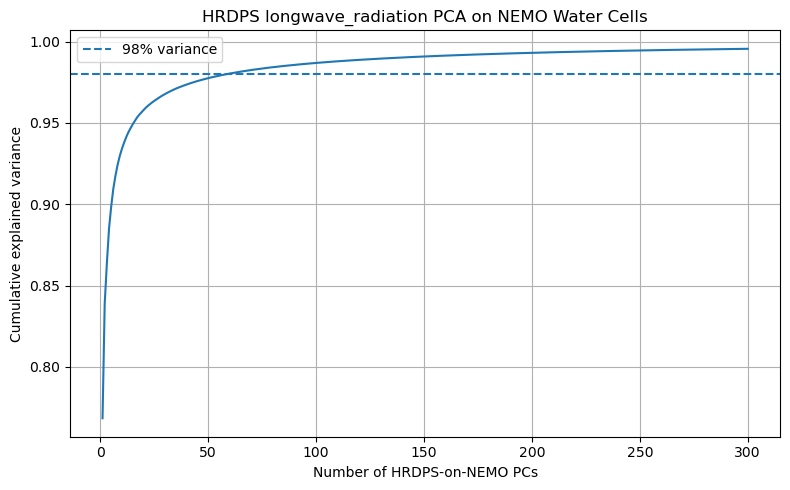

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold,linestyle="--",label="98% variance")
plt.xlabel("Number of HRDPS-on-NEMO PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS longwave_radiation PCA on NEMO Water Cells")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]
n_hrdps_pcs = threshold_indices[0] + 1
print("Selected HRDPS PCs:", n_hrdps_pcs)
print("Cumulative variance:",hrdps_cumulative_variance[n_hrdps_pcs - 1])

Selected HRDPS PCs: 59
Cumulative variance: 0.9801047


In [34]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:  ", hrdps_val_scores.shape)
print("HRDPS test scores: ", hrdps_test_scores.shape)

HRDPS train scores: (8760, 59)
HRDPS val scores:   (2920, 59)
HRDPS test scores:  (2912, 59)


In [35]:
max_canrcm_pcs = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs,svd_solver="randomized",random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

print("CanRCM PCA components:", pca_canrcm.components_.shape)
print("CanRCM train scores:", canrcm_train_scores_all.shape)
print("CanRCM val scores:  ", canrcm_val_scores_all.shape)
print("CanRCM test scores: ", canrcm_test_scores_all.shape)

CanRCM PCA components: (100, 340)
CanRCM train scores: (8760, 100)
CanRCM val scores:   (2920, 100)
CanRCM test scores:  (2912, 100)


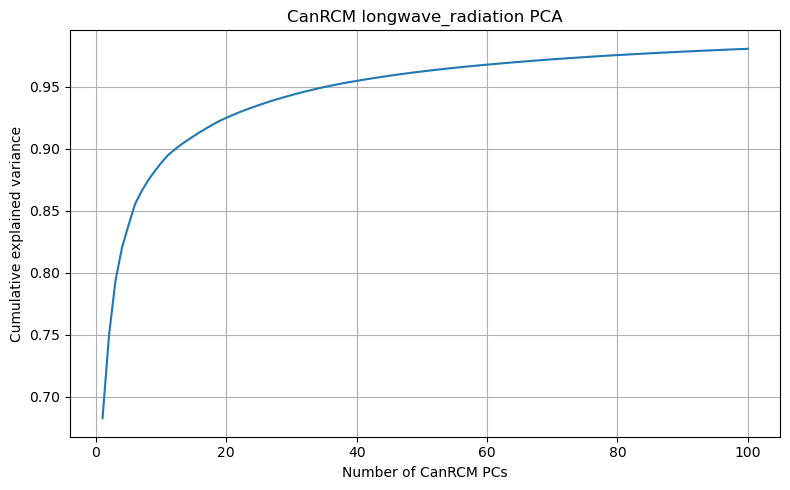

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(canrcm_cumulative_variance) + 1),canrcm_cumulative_variance)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM longwave_radiation PCA")
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
canrcm_pc_candidates = range(1,max_canrcm_pcs + 1)
val_r2_scores = []
for n_canrcm_pcs_candidate in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:,:n_canrcm_pcs_candidate]
    X_val_pc = canrcm_val_scores_all[:,:n_canrcm_pcs_candidate]
    model = LinearRegression()
    model.fit(X_train_pc,hrdps_train_scores)
    hrdps_val_scores_pred_candidate = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores,hrdps_val_scores_pred_candidate,multioutput="variance_weighted")
    val_r2_scores.append(val_r2)
val_r2_scores = np.array(val_r2_scores)

In [38]:
best_index = np.nanargmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]
best_val_r2 = val_r2_scores[best_index]

print("Best number of CanRCM PCs:", n_canrcm_pcs)
print("Best validation PC-space R²:", best_val_r2)

Best number of CanRCM PCs: 73
Best validation PC-space R²: 0.6189713478088379


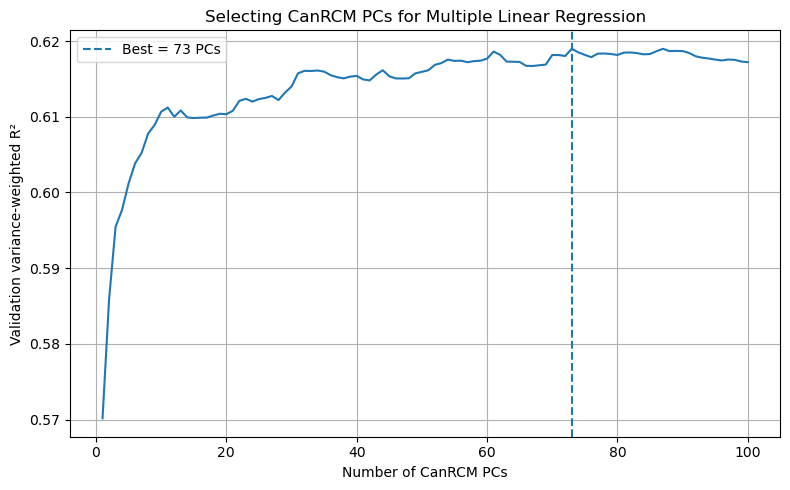

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates),val_r2_scores)
plt.axvline(n_canrcm_pcs,linestyle="--",label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting CanRCM PCs for Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
X_train_pc_final = canrcm_train_scores_all[:,:n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:,:n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:,:n_canrcm_pcs]

In [43]:
tf.keras.utils.set_random_seed(42)

print("CanRCM predictor PCs:", X_train_pc_final.shape[1])
print("HRDPS target PCs:", hrdps_train_scores.shape[1])

CanRCM predictor PCs: 73
HRDPS target PCs: 59


In [49]:


def get_aligned_split_times(ds_canrcm_split, ds_hrdps_split, split_name):
    canrcm_times = pd.DatetimeIndex([time_to_string(value) for value in ds_canrcm_split["time"].values])
    hrdps_times = pd.DatetimeIndex([time_to_string(value) for value in ds_hrdps_split["time_counter"].values])

    if len(canrcm_times) != len(hrdps_times):
        raise ValueError(f"{split_name}: CanRCM and HRDPS have different numbers of timestamps.")

    if not np.array_equal(canrcm_times.values, hrdps_times.values):
        mismatch_indices = np.where(canrcm_times.values != hrdps_times.values)[0]
        first_mismatch = int(mismatch_indices[0])
        raise ValueError(f"{split_name}: timestamp mismatch at index {first_mismatch}.")

    if canrcm_times.has_duplicates:
        raise ValueError(f"{split_name}: duplicate timestamps were found.")

    if not canrcm_times.is_monotonic_increasing:
        raise ValueError(f"{split_name}: timestamps are not strictly increasing.")

    time_differences = np.diff(canrcm_times.values)
    gap_indices = np.where(time_differences != expected_step)[0]

    print(f"\n{split_name}")
    print("Number of aligned timestamps:", len(canrcm_times))
    print("First timestamp:", canrcm_times[0])
    print("Last timestamp:", canrcm_times[-1])
    print("Number of non-3-hour gaps:", len(gap_indices))

    for gap_index in gap_indices[:10]:
        print("Gap:", canrcm_times[gap_index], "to", canrcm_times[gap_index + 1])

    return canrcm_times.to_numpy(dtype="datetime64[ns]"), gap_indices


train_times, train_gap_indices = get_aligned_split_times(ds_canrcm_train, ds_hrdps_train, "Training 2009-2011")
val_times, val_gap_indices = get_aligned_split_times(ds_canrcm_val, ds_hrdps_val, "Validation 2008")
test_times, test_gap_indices = get_aligned_split_times(ds_canrcm_test, ds_hrdps_test, "Testing 2012")


Training 2009-2011
Number of aligned timestamps: 8760
First timestamp: 2009-01-01 00:00:00
Last timestamp: 2011-12-31 21:00:00
Number of non-3-hour gaps: 0

Validation 2008
Number of aligned timestamps: 2920
First timestamp: 2008-01-01 00:00:00
Last timestamp: 2008-12-31 21:00:00
Number of non-3-hour gaps: 1
Gap: 2008-02-28 21:00:00 to 2008-03-01 00:00:00

Testing 2012
Number of aligned timestamps: 2912
First timestamp: 2012-01-01 00:00:00
Last timestamp: 2012-12-31 21:00:00
Number of non-3-hour gaps: 2
Gap: 2012-02-28 21:00:00 to 2012-03-01 00:00:00
Gap: 2012-10-03 21:00:00 to 2012-10-05 00:00:00


In [46]:
# Standardize predictor and target PC scores using training data only

predictor_pc_scaler = StandardScaler()
hrdps_pc_scaler = StandardScaler()

X_train_pc_scaled = predictor_pc_scaler.fit_transform(X_train_pc_final).astype(np.float32)
X_val_pc_scaled = predictor_pc_scaler.transform(X_val_pc_final).astype(np.float32)

Y_train_pc_scaled = hrdps_pc_scaler.fit_transform(hrdps_train_scores).astype(np.float32)
Y_val_pc_scaled = hrdps_pc_scaler.transform(hrdps_val_scores).astype(np.float32)

print("Scaled training predictors:", X_train_pc_scaled.shape)
print("Scaled validation predictors:", X_val_pc_scaled.shape)
print("Scaled training targets:", Y_train_pc_scaled.shape)
print("Scaled validation targets:", Y_val_pc_scaled.shape)

Scaled training predictors: (8760, 73)
Scaled validation predictors: (2920, 73)
Scaled training targets: (8760, 59)
Scaled validation targets: (2920, 59)


In [47]:
# Create sequence-to-one samples without crossing temporal gaps

expected_step = np.timedelta64(3, "h")
def make_gap_safe_sequences(predictors, targets, times, lookback):
    if len(predictors) != len(targets) or len(predictors) != len(times):
        raise ValueError("Predictors, targets, and timestamps must have the same length.")

    if lookback < 1:
        raise ValueError("lookback must be at least 1.")

    time_differences = np.diff(times)
    segment_ids = np.zeros(len(times), dtype=np.int32)
    segment_ids[1:] = np.cumsum(time_differences != expected_step)

    sequence_list = []
    target_list = []
    end_index_list = []

    for end_index in range(lookback - 1, len(times)):
        start_index = end_index - lookback + 1

        if segment_ids[start_index] != segment_ids[end_index]:
            continue

        sequence_list.append(predictors[start_index:end_index + 1])
        target_list.append(targets[end_index])
        end_index_list.append(end_index)

    if not sequence_list:
        raise ValueError(f"No valid sequences were created for lookback={lookback}.")

    X_sequences = np.stack(sequence_list).astype(np.float32)
    Y_sequences = np.stack(target_list).astype(np.float32)
    end_indices = np.asarray(end_index_list, dtype=np.int64)
    target_times = times[end_indices]

    return X_sequences, Y_sequences, end_indices, target_times

In [ ]:
# Check sequence counts for the three lookback windows

lookback_windows = [8, 16, 32]

for lookback in lookback_windows:
    X_train_sequence_check, Y_train_sequence_check, train_end_indices_check, train_target_times_check = make_gap_safe_sequences(
        X_train_pc_scaled,
        Y_train_pc_scaled,
        train_times,
        lookback,
    )

    X_val_sequence_check, Y_val_sequence_check, val_end_indices_check, val_target_times_check = make_gap_safe_sequences(
        X_val_pc_scaled,
        Y_val_pc_scaled,
        val_times,
        lookback,
    )

    print(f"\nLookback {lookback} timesteps ({lookback * 3} hours)")
    print("Training sequences:", X_train_sequence_check.shape)
    print("Validation sequences:", X_val_sequence_check.shape)
    print("First validation target time:", val_target_times_check[0])
    print("Last validation target time:", val_target_times_check[-1])

    del X_train_sequence_check
    del Y_train_sequence_check
    del train_end_indices_check
    del train_target_times_check
    del X_val_sequence_check
    del Y_val_sequence_check
    del val_end_indices_check
    del val_target_times_check
    gc.collect()


Lookback 8 timesteps (24 hours)
Training sequences: (8753, 8, 73)
Validation sequences: (2906, 8, 73)
First validation target time: 2008-01-01T21:00:00.000000000
Last validation target time: 2008-12-31T21:00:00.000000000

Lookback 16 timesteps (48 hours)
Training sequences: (8745, 16, 73)
Validation sequences: (2890, 16, 73)
First validation target time: 2008-01-02T21:00:00.000000000
Last validation target time: 2008-12-31T21:00:00.000000000

Lookback 32 timesteps (96 hours)
Training sequences: (8729, 32, 73)
Validation sequences: (2858, 32, 73)
First validation target time: 2008-01-04T21:00:00.000000000
Last validation target time: 2008-12-31T21:00:00.000000000


In [50]:
# Define the residual causal TCN block

def residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate, l2_strength, block_number):
    regularizer = tf.keras.regularizers.l2(l2_strength)
    shortcut = x

    y = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, kernel_regularizer=regularizer, name=f"block_{block_number}_conv_1")(x)
    y = layers.LayerNormalization(name=f"block_{block_number}_norm_1")(y)
    y = layers.Activation("relu", name=f"block_{block_number}_relu_1")(y)
    y = layers.SpatialDropout1D(dropout_rate, name=f"block_{block_number}_dropout_1")(y)

    y = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, kernel_regularizer=regularizer, name=f"block_{block_number}_conv_2")(y)
    y = layers.LayerNormalization(name=f"block_{block_number}_norm_2")(y)
    y = layers.Activation("relu", name=f"block_{block_number}_relu_2")(y)
    y = layers.SpatialDropout1D(dropout_rate, name=f"block_{block_number}_dropout_2")(y)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same", kernel_regularizer=regularizer, name=f"block_{block_number}_projection")(shortcut)

    output = layers.Add(name=f"block_{block_number}_residual_add")([shortcut, y])
    output = layers.Activation("relu", name=f"block_{block_number}_output_relu")(output)

    return output

In [51]:
#  Define the complete sequence-to-one TCN

def build_pc_tcn(lookback, n_input_pcs, n_output_pcs, filters, kernel_size, dilations, dropout_rate, l2_strength):
    inputs = layers.Input(shape=(lookback, n_input_pcs), name="canrcm_longwave_pc_sequence")
    x = inputs

    for block_number, dilation_rate in enumerate(dilations, start=1):
        x = residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate, l2_strength, block_number)

    x = layers.Cropping1D(cropping=(lookback - 1, 0), name="keep_final_timestep")(x)
    x = layers.Flatten(name="flatten_final_timestep")(x)

    outputs = layers.Dense(
        n_output_pcs,
        activation="linear",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
        name="hrdps_longwave_pc_output",
    )(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name=f"longwave_pc_tcn_lookback_{lookback}")

In [53]:
# Define the small validation-search space

tcn_architectures = [
    {
        "architecture": "small_16_filters",
        "filters": 16,
        "kernel_size": 3,
        "dilations": (1, 2, 4),
        "dropout_rate": 0.10,
        "l2_strength": 1e-5,
        "learning_rate": 1e-3,
        "batch_size": 64,
    },
    {
        "architecture": "small_32_filters",
        "filters": 32,
        "kernel_size": 3,
        "dilations": (1, 2, 4),
        "dropout_rate": 0.20,
        "l2_strength": 1e-5,
        "learning_rate": 5e-4,
        "batch_size": 64,
    },
]

tcn_output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn"
os.makedirs(tcn_output_dir, exist_ok=True)

tcn_search_results = []
tcn_histories = {}

In [56]:
# Train all TCN candidates using training and validation data only
n_canrcm_pcs = int(n_canrcm_pcs)
n_hrdps_pcs = int(n_hrdps_pcs)
for lookback in lookback_windows:
    X_train_tcn, Y_train_tcn, train_end_indices, train_target_times = make_gap_safe_sequences(
        X_train_pc_scaled,
        Y_train_pc_scaled,
        train_times,
        lookback,
    )

    X_val_tcn, Y_val_tcn, val_end_indices, val_target_times = make_gap_safe_sequences(
        X_val_pc_scaled,
        Y_val_pc_scaled,
        val_times,
        lookback,
    )

    for trial_number, architecture_config in enumerate(tcn_architectures, start=1):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(1000 + lookback + trial_number)

        architecture_name = architecture_config["architecture"]
        checkpoint_name = f"{architecture_name}_lookback_{lookback}.weights.h5"
        checkpoint_path_tcn = os.path.join(tcn_output_dir, checkpoint_name)

        pc_tcn = build_pc_tcn(
            lookback=lookback,
            n_input_pcs=n_canrcm_pcs,
            n_output_pcs=n_hrdps_pcs,
            filters=architecture_config["filters"],
            kernel_size=architecture_config["kernel_size"],
            dilations=architecture_config["dilations"],
            dropout_rate=architecture_config["dropout_rate"],
            l2_strength=architecture_config["l2_strength"],
        )

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=architecture_config["learning_rate"],
            clipnorm=1.0,
        )

        pc_tcn.compile(
            optimizer=optimizer,
            loss="mse",
            metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
        )

        callbacks_tcn = [
            tf.keras.callbacks.ModelCheckpoint(
                checkpoint_path_tcn,
                monitor="val_loss",
                mode="min",
                save_best_only=True,
                save_weights_only=True,
                verbose=1,
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=12,
                min_delta=1e-4,
                restore_best_weights=True,
                verbose=1,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                mode="min",
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=1,
            ),
        ]

        history_tcn = pc_tcn.fit(
            X_train_tcn,
            Y_train_tcn,
            validation_data=(X_val_tcn, Y_val_tcn),
            epochs=150,
            batch_size=architecture_config["batch_size"],
            shuffle=True,
            callbacks=callbacks_tcn,
            verbose=2,
        )

        best_epoch = int(np.argmin(history_tcn.history["val_loss"]) + 1)
        best_validation_loss = float(np.min(history_tcn.history["val_loss"]))
        best_validation_mae = float(history_tcn.history["val_mae"][best_epoch - 1])
        receptive_field = 1 + 2 * (architecture_config["kernel_size"] - 1) * sum(architecture_config["dilations"])
        history_key = f"{architecture_name}_lookback_{lookback}"

        tcn_histories[history_key] = history_tcn.history

        tcn_search_results.append(
            {
                "lookback": lookback,
                "hours": lookback * 3,
                "architecture": architecture_name,
                "filters": architecture_config["filters"],
                "kernel_size": architecture_config["kernel_size"],
                "dilations": architecture_config["dilations"],
                "dropout_rate": architecture_config["dropout_rate"],
                "l2_strength": architecture_config["l2_strength"],
                "learning_rate": architecture_config["learning_rate"],
                "batch_size": architecture_config["batch_size"],
                "receptive_field": receptive_field,
                "best_epoch": best_epoch,
                "best_val_loss": best_validation_loss,
                "best_val_mae": best_validation_mae,
                "checkpoint_path": checkpoint_path_tcn,
            }
        )

        del pc_tcn
        gc.collect()

    del X_train_tcn
    del Y_train_tcn
    del train_end_indices
    del train_target_times
    del X_val_tcn
    del Y_val_tcn
    del val_end_indices
    del val_target_times
    gc.collect()

Epoch 1/150


2026-07-21 15:20:31.695681: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-21 15:20:39.232352: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Epoch 1: val_loss improved from None to 1.19047, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_16_filters_lookback_8.weights.h5

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_16_filters_lookback_8.weights.h5
137/137 - 9s - 62ms/step - loss: 1.4105 - mae: 0.8703 - val_loss: 1.1905 - val_mae: 0.7831 - learning_rate: 0.0010
Epoch 2/150

Epoch 2: val_loss improved from 1.19047 to 1.12986, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_16_filters_lookback_8.weights.h5

Epoch 2: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_16_filters_lookback_8.weights.h5
137/137 - 2s - 11ms/step - loss: 1.0758 - mae: 0.7400 - val_loss: 1.1299 - val_mae: 0.7559 - learning_rate: 0.0010
Epoch 3/150

Epoch 3: val_loss improved from 1.12986 to 1.107

2026-07-21 15:21:53.709490: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-21 15:22:02.214917: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Epoch 1: val_loss improved from None to 1.35291, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_8.weights.h5

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_8.weights.h5
137/137 - 9s - 69ms/step - loss: 1.9456 - mae: 1.0504 - val_loss: 1.3529 - val_mae: 0.8535 - learning_rate: 5.0000e-04
Epoch 2/150

Epoch 2: val_loss improved from 1.35291 to 1.22540, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_8.weights.h5

Epoch 2: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_8.weights.h5
137/137 - 2s - 14ms/step - loss: 1.2839 - mae: 0.8351 - val_loss: 1.2254 - val_mae: 0.7998 - learning_rate: 5.0000e-04
Epoch 3/150

Epoch 3: val_loss improved from 1.22540 

...


Epoch 1: val_loss improved from None to 1.34356, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_16.weights.h5

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_16.weights.h5
137/137 - 9s - 67ms/step - loss: 1.9300 - mae: 1.0461 - val_loss: 1.3436 - val_mae: 0.8489 - learning_rate: 5.0000e-04
Epoch 2/150

Epoch 2: val_loss improved from 1.34356 to 1.22145, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_16.weights.h5

Epoch 2: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_16.weights.h5
137/137 - 2s - 18ms/step - loss: 1.2652 - mae: 0.8273 - val_loss: 1.2215 - val_mae: 0.7976 - learning_rate: 5.0000e-04
Epoch 3/150

Epoch 3: val_loss improved from 1.22

2026-07-21 15:27:10.010638: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-21 15:27:18.126313: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Epoch 1: val_loss improved from None to 1.18410, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_16_filters_lookback_32.weights.h5

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_16_filters_lookback_32.weights.h5
137/137 - 9s - 67ms/step - loss: 1.4300 - mae: 0.8744 - val_loss: 1.1841 - val_mae: 0.7814 - learning_rate: 0.0010
Epoch 2/150

Epoch 2: val_loss improved from 1.18410 to 1.12479, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_16_filters_lookback_32.weights.h5

Epoch 2: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_16_filters_lookback_32.weights.h5
137/137 - 3s - 19ms/step - loss: 1.0686 - mae: 0.7372 - val_loss: 1.1248 - val_mae: 0.7542 - learning_rate: 0.0010
Epoch 3/150

Epoch 3: val_loss improved from 1.12479 to 1

2026-07-21 15:29:12.580482: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-21 15:29:21.970931: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Epoch 1: val_loss improved from None to 1.35503, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_32.weights.h5

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_32.weights.h5
137/137 - 11s - 77ms/step - loss: 1.9798 - mae: 1.0573 - val_loss: 1.3550 - val_mae: 0.8526 - learning_rate: 5.0000e-04
Epoch 2/150

Epoch 2: val_loss improved from 1.35503 to 1.22849, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_32.weights.h5

Epoch 2: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_32_filters_lookback_32.weights.h5
137/137 - 3s - 25ms/step - loss: 1.2908 - mae: 0.8368 - val_loss: 1.2285 - val_mae: 0.8003 - learning_rate: 5.0000e-04
Epoch 3/150

Epoch 3: val_loss improved from 1.2

In [57]:
tcn_search_table = pd.DataFrame(tcn_search_results)
tcn_search_table = tcn_search_table.sort_values("best_val_loss").reset_index(drop=True)

tcn_search_table

,lookback,hours,architecture,filters,kernel_size,dilations,dropout_rate,l2_strength,learning_rate,batch_size,receptive_field,best_epoch,best_val_loss,best_val_mae,checkpoint_path
0,16,48,small_16_filters,16,3,"(1, 2, 4)",0.1,0.00001,0.0010,64,29,30,1.041393,0.715060,/ocean/dtaneja/MOAD/analysis-dishika/notebooks...
1,8,24,small_16_filters,16,3,"(1, 2, 4)",0.1,0.00001,0.0010,64,29,36,1.043259,0.715361,/ocean/dtaneja/MOAD/analysis-dishika/notebooks...
2,32,96,small_16_filters,16,3,"(1, 2, 4)",0.1,0.00001,0.0010,64,29,33,1.043995,0.716871,/ocean/dtaneja/MOAD/analysis-dishika/notebooks...
3,16,48,small_32_filters,32,3,"(1, 2, 4)",0.2,0.00001,0.0005,64,29,35,1.045340,0.716867,/ocean/dtaneja/MOAD/analysis-dishika/notebooks...
4,8,24,small_32_filters,32,3,"(1, 2, 4)",0.2,0.00001,0.0005,64,29,41,1.045350,0.717125,/ocean/dtaneja/MOAD/analysis-dishika/notebooks...
5,32,96,small_32_filters,32,3,"(1, 2, 4)",0.2,0.00001,0.0005,64,29,37,1.046199,0.717524,/ocean/dtaneja/MOAD/analysis-dishika/notebooks...


In [58]:
# Select the best TCN using validation loss only

best_tcn_result = tcn_search_table.iloc[0].to_dict()
best_lookback = int(best_tcn_result["lookback"])
best_architecture_name = best_tcn_result["architecture"]

best_architecture_config = next(
    config for config in tcn_architectures
    if config["architecture"] == best_architecture_name
)

print("Selected lookback:", best_lookback, "timesteps")
print("Selected history length:", best_lookback * 3, "hours")
print("Selected architecture:", best_architecture_name)
print("Selected validation loss:", best_tcn_result["best_val_loss"])
print("Selected checkpoint:", best_tcn_result["checkpoint_path"])

Selected lookback: 16 timesteps
Selected history length: 48 hours
Selected architecture: small_16_filters
Selected validation loss: 1.0413929224014282
Selected checkpoint: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/small_16_filters_lookback_16.weights.h5


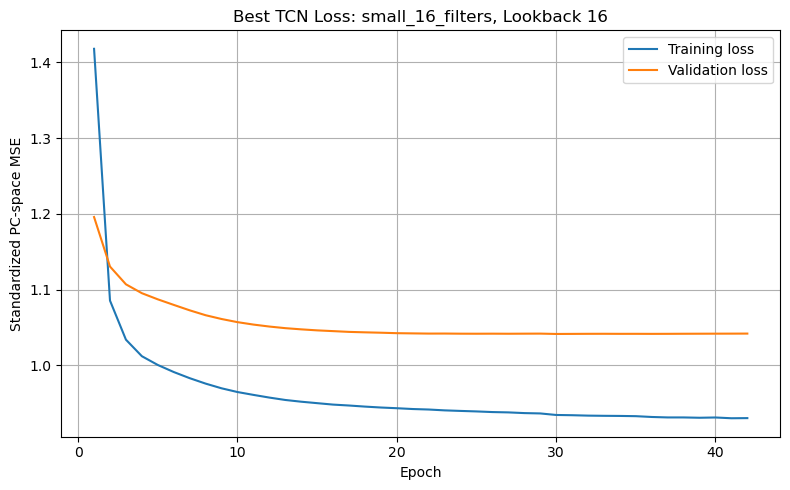

In [59]:
# Plot the best TCN training history

best_history_key = f"{best_architecture_name}_lookback_{best_lookback}"
best_history = tcn_histories[best_history_key]
best_epochs = np.arange(1, len(best_history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(best_epochs, best_history["loss"], label="Training loss")
plt.plot(best_epochs, best_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Standardized PC-space MSE")
plt.title(f"Best TCN Loss: {best_architecture_name}, Lookback {best_lookback}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [60]:
# Rebuild and load the selected TCN

tf.keras.backend.clear_session()

best_pc_tcn = build_pc_tcn(
    lookback=best_lookback,
    n_input_pcs=n_canrcm_pcs,
    n_output_pcs=n_hrdps_pcs,
    filters=best_architecture_config["filters"],
    kernel_size=best_architecture_config["kernel_size"],
    dilations=best_architecture_config["dilations"],
    dropout_rate=best_architecture_config["dropout_rate"],
    l2_strength=best_architecture_config["l2_strength"],
)

best_pc_tcn.load_weights(best_tcn_result["checkpoint_path"])
best_pc_tcn.summary()

Model: "longwave_pc_tcn_lookback_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ canrcm_longwave_pc… │ (None, 16, 73)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_conv_1      │ (None, 16, 16)    │      3,520 │ canrcm_longwave_… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_norm_1      │ (None, 16, 16)    │         32 │ block_1_conv_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_relu_1      │ (None, 16, 16)    │          0 │ block_1_norm_1[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_dropout_1   │ (None, 16, 16)    │          0 │ block_1_relu_1[0… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_conv_2      │ (None, 16, 16)    │        784 │ block_1_dropout_… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_norm_2      │ (None, 16, 16)    │         32 │ block_1_conv_2[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_relu_2      │ (None, 16, 16)    │          0 │ block_1_norm_2[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_projection  │ (None, 16, 16)    │      1,184 │ canrcm_longwave_… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_dropout_2   │ (None, 16, 16)    │          0 │ block_1_relu_2[0… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_residual_a… │ (None, 16, 16)    │          0 │ block_1_projecti… │
│ (Add)               │                   │            │ block_1_dropout_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_output_relu │ (None, 16, 16)    │          0 │ block_1_residual… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_conv_1      │ (None, 16, 16)    │        784 │ block_1_output_r… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_norm_1      │ (None, 16, 16)    │         32 │ block_2_conv_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_relu_1      │ (None, 16, 16)    │          0 │ block_2_norm_1[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_dropout_1   │ (None, 16, 16)    │          0 │ block_2_relu_1[0… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_conv_2      │ (None, 16, 16)    │        784 │ block_2_dropout_

 Total params: 9,819 (38.36 KB)

 Trainable params: 9,819 (38.36 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Generate validation predictions from the selected TCN

X_val_tcn, Y_val_tcn, val_tcn_end_indices, val_tcn_target_times = make_gap_safe_sequences(
    X_val_pc_scaled,
    Y_val_pc_scaled,
    val_times,
    best_lookback,
)

hrdps_val_scores_pred_tcn_scaled = best_pc_tcn.predict(
    X_val_tcn,
    batch_size=256,
    verbose=1,
)

hrdps_val_scores_pred_tcn = hrdps_pc_scaler.inverse_transform(
    hrdps_val_scores_pred_tcn_scaled
).astype(np.float32)

hrdps_val_scores_tcn_actual = hrdps_val_scores[val_tcn_end_indices]
X_hrdps_val_tcn_actual = X_hrdps_val[val_tcn_end_indices]

print("TCN validation PC predictions:", hrdps_val_scores_pred_tcn.shape)
print("TCN validation target fields:", X_hrdps_val_tcn_actual.shape)

2026-07-21 15:32:11.419076: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
TCN validation PC predictions: (2890, 59)
TCN validation target fields: (2890, 81383)


In [62]:
# Define the PCA plus FCNN baseline

def build_pc_fcnn_baseline(n_input_pcs, n_output_pcs):
    regularizer = tf.keras.regularizers.l2(1e-4)

    inputs = layers.Input(shape=(n_input_pcs,), name="canrcm_longwave_pc_input")
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizer, name="dense_1")(inputs)
    x = layers.Dropout(0.20, name="dropout_1")(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizer, name="dense_2")(x)
    x = layers.Dropout(0.20, name="dropout_2")(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=regularizer, name="dense_3")(x)
    outputs = layers.Dense(n_output_pcs, activation="linear", name="hrdps_longwave_pc_output")(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="longwave_pc_fcnn_baseline")

In [63]:
# Train the PCA plus FCNN baseline using validation loss

fcnn_checkpoint_path = os.path.join(
    tcn_output_dir,
    "best_longwave_pc_fcnn_baseline.weights.h5",
)

tf.keras.utils.set_random_seed(42)

pc_fcnn_baseline = build_pc_fcnn_baseline(
    n_canrcm_pcs,
    n_hrdps_pcs,
)

pc_fcnn_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="mse",
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
)

fcnn_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        fcnn_checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=12,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_fcnn_baseline = pc_fcnn_baseline.fit(
    X_train_pc_scaled,
    Y_train_pc_scaled,
    validation_data=(X_val_pc_scaled, Y_val_pc_scaled),
    epochs=200,
    batch_size=64,
    shuffle=True,
    callbacks=fcnn_callbacks,
    verbose=2,
)

pc_fcnn_baseline.load_weights(fcnn_checkpoint_path)

Epoch 1/200

Epoch 1: val_loss improved from None to 1.11417, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/best_longwave_pc_fcnn_baseline.weights.h5

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/best_longwave_pc_fcnn_baseline.weights.h5
137/137 - 2s - 16ms/step - loss: 1.0580 - mae: 0.7165 - val_loss: 1.1142 - val_mae: 0.7379 - learning_rate: 3.0000e-04
Epoch 2/200

Epoch 2: val_loss improved from 1.11417 to 1.11238, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/best_longwave_pc_fcnn_baseline.weights.h5

Epoch 2: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_tcn/best_longwave_pc_fcnn_baseline.weights.h5
137/137 - 1s - 4ms/step - loss: 1.0259 - mae: 0.7015 - val_loss: 1.1124 - val_mae: 0.7373 - learning_rate: 3.0000e-04
Epoch 3/200

Epoch 3: val_loss

In [ ]:
# Generate validation predictions for LR and FCNN on the TCN target timestamps

lr_model = LinearRegression()
lr_model.fit(X_train_pc_final, hrdps_train_scores)

hrdps_val_scores_pred_lr = lr_model.predict(
    X_val_pc_final[val_tcn_end_indices]
).astype(np.float32)

hrdps_val_scores_pred_fcnn_scaled = pc_fcnn_baseline.predict(
    X_val_pc_scaled[val_tcn_end_indices],
    batch_size=256,
    verbose=1,
)

hrdps_val_scores_pred_fcnn = hrdps_pc_scaler.inverse_transform(
    hrdps_val_scores_pred_fcnn_scaled
).astype(np.float32)

print("PCA + LR validation PC predictions:", hrdps_val_scores_pred_lr.shape)
print("PCA + FCNN validation PC predictions:", hrdps_val_scores_pred_fcnn.shape)
print("PCA + TCN validation PC predictions:", hrdps_val_scores_pred_tcn.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
PCA + LR validation PC predictions: (2890, 59)
PCA + FCNN validation PC predictions: (2890, 59)
PCA + TCN validation PC predictions: (2890, 59)


2026-07-21 15:33:01.976781: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [ ]:
# Use the 2012 test set only after selecting the final TCN

X_test_pc_scaled = predictor_pc_scaler.transform(X_test_pc_final).astype(np.float32)
Y_test_pc_scaled = hrdps_pc_scaler.transform(hrdps_test_scores).astype(np.float32)

X_test_tcn, Y_test_tcn, test_tcn_end_indices, test_tcn_target_times = make_gap_safe_sequences(
    X_test_pc_scaled,
    Y_test_pc_scaled,
    test_times,
    best_lookback,
)

hrdps_test_scores_pred_tcn_scaled = best_pc_tcn.predict(
    X_test_tcn,
    batch_size=256,
    verbose=1,
)

hrdps_test_scores_pred_tcn = hrdps_pc_scaler.inverse_transform(
    hrdps_test_scores_pred_tcn_scaled
).astype(np.float32)

hrdps_test_scores_tcn_actual = hrdps_test_scores[test_tcn_end_indices]
X_hrdps_test_tcn_actual = X_hrdps_test[test_tcn_end_indices]

hrdps_test_scores_pred_lr = lr_model.predict(
    X_test_pc_final[test_tcn_end_indices]
).astype(np.float32)

hrdps_test_scores_pred_fcnn_scaled = pc_fcnn_baseline.predict(
    X_test_pc_scaled[test_tcn_end_indices],
    batch_size=256,
    verbose=1,
)

hrdps_test_scores_pred_fcnn = hrdps_pc_scaler.inverse_transform(
    hrdps_test_scores_pred_fcnn_scaled
).astype(np.float32)

print("Final test target times:", len(test_tcn_target_times))
print("First test target time:", test_tcn_target_times[0])
print("Last test target time:", test_tcn_target_times[-1])

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Final test target times: 2867
First test target time: 2012-01-02T21:00:00.000000000
Last test target time: 2012-12-31T21:00:00.000000000


In [ ]:
# Define field reconstruction and evaluation metrics

selected_hrdps_components = pca_hrdps.components_[:n_hrdps_pcs, :]


def reconstruct_from_hrdps_pcs(pc_scores):
    reconstructed = np.dot(pc_scores, selected_hrdps_components) + pca_hrdps.mean_
    return reconstructed.astype(np.float32)


def calculate_pc_and_field_metrics(true_scores, predicted_scores, true_fields):
    predicted_fields = reconstruct_from_hrdps_pcs(predicted_scores)
    field_error = predicted_fields - true_fields

    field_rmse = float(np.sqrt(np.mean(field_error**2, dtype=np.float64)))
    true_standard_deviation = float(np.std(true_fields, dtype=np.float64))
    normalized_rmse = field_rmse / true_standard_deviation if true_standard_deviation > 0 else np.nan

    true_domain_mean = np.mean(true_fields, axis=1)
    predicted_domain_mean = np.mean(predicted_fields, axis=1)
    pc_error = predicted_scores - true_scores

    metrics = {
        "rmse": field_rmse,
        "normalized_rmse": float(normalized_rmse),
        "mae": float(np.mean(np.abs(field_error), dtype=np.float64)),
        "bias": float(np.mean(field_error, dtype=np.float64)),
        "grid_cell_r2": float(r2_score(true_fields, predicted_fields, multioutput="variance_weighted")),
        "domain_mean_time_series_r2": float(r2_score(true_domain_mean, predicted_domain_mean)),
        "pc_space_r2": float(r2_score(true_scores, predicted_scores, multioutput="variance_weighted")),
        "pc_rmse": float(np.sqrt(np.mean(pc_error**2, dtype=np.float64))),
        "number_of_times": int(true_fields.shape[0]),
        "number_of_grid_cells": int(true_fields.shape[1]),
    }

    del predicted_fields
    del field_error
    gc.collect()

    return metrics

In [ ]:
# Calculate validation and test metrics for all three models

validation_predictions = {
    "PCA + Linear Regression": hrdps_val_scores_pred_lr,
    "PCA + FCNN": hrdps_val_scores_pred_fcnn,
    "PCA + TCN": hrdps_val_scores_pred_tcn,
}

test_predictions = {
    "PCA + Linear Regression": hrdps_test_scores_pred_lr,
    "PCA + FCNN": hrdps_test_scores_pred_fcnn,
    "PCA + TCN": hrdps_test_scores_pred_tcn,
}

therm_rad_units = ds_hrdps_train["therm_rad"].attrs.get(
    "units",
    "HRDPS therm_rad units",
)

comparison_rows = []

for model_name, predicted_scores in validation_predictions.items():
    validation_metrics = calculate_pc_and_field_metrics(
        hrdps_val_scores_tcn_actual,
        predicted_scores,
        X_hrdps_val_tcn_actual,
    )

    comparison_rows.append(
        {
            "model": model_name,
            "split": "validation",
            "units": therm_rad_units,
            **validation_metrics,
        }
    )

for model_name, predicted_scores in test_predictions.items():
    test_metrics = calculate_pc_and_field_metrics(
        hrdps_test_scores_tcn_actual,
        predicted_scores,
        X_hrdps_test_tcn_actual,
    )

    comparison_rows.append(
        {
            "model": model_name,
            "split": "test",
            "units": therm_rad_units,
            **test_metrics,
        }
    )

model_comparison_table = pd.DataFrame(comparison_rows)
model_comparison_table

,model,split,units,rmse,normalized_rmse,mae,bias,grid_cell_r2,domain_mean_time_series_r2,pc_space_r2,pc_rmse,number_of_times,number_of_grid_cells
0,PCA + Linear Regression,validation,W/m^2,22.278843,0.623040,17.482006,1.040415,0.607116,0.744790,0.619852,805.525496,2890,81383
1,PCA + FCNN,validation,W/m^2,22.740232,0.635943,17.708461,1.966152,0.590674,0.722510,0.603065,823.117826,2890,81383
2,PCA + TCN,validation,W/m^2,22.775762,0.636937,17.858276,2.432405,0.589394,0.720431,0.601758,824.471852,2890,81383
3,PCA + Linear Regression,test,W/m^2,21.801971,0.671082,16.939472,3.891098,0.544280,0.707413,0.560193,784.369394,2867,81383
4,PCA + FCNN,test,W/m^2,22.459253,0.691314,17.183800,4.586227,0.516388,0.669070,0.531506,809.545791,2867,81383
5,PCA + TCN,test,W/m^2,22.886692,0.704471,17.754944,5.288532,0.497805,0.643176,0.512393,825.893705,2867,81383


In [ ]:
# Display validation and final test comparisons

validation_comparison = model_comparison_table[
    model_comparison_table["split"] == "validation"
].sort_values("rmse")

test_comparison = model_comparison_table[
    model_comparison_table["split"] == "test"
].sort_values("rmse")

print("Validation comparison")
print(validation_comparison.to_string(index=False))

print("\nFinal test comparison")
print(test_comparison.to_string(index=False))

Validation comparison
                  model      split units      rmse  normalized_rmse       mae     bias  grid_cell_r2  domain_mean_time_series_r2  pc_space_r2    pc_rmse  number_of_times  number_of_grid_cells
PCA + Linear Regression validation W/m^2 22.278843         0.623040 17.482006 1.040415      0.607116                    0.744790     0.619852 805.525496             2890                 81383
             PCA + FCNN validation W/m^2 22.740232         0.635943 17.708461 1.966152      0.590674                    0.722510     0.603065 823.117826             2890                 81383
              PCA + TCN validation W/m^2 22.775762         0.636937 17.858276 2.432405      0.589394                    0.720431     0.601758 824.471852             2890                 81383

Final test comparison
                  model split units      rmse  normalized_rmse       mae     bias  grid_cell_r2  domain_mean_time_series_r2  pc_space_r2    pc_rmse  number_of_times  number_of_grid_cells
